### [Trading Options with Volatility Surface](https://medium.com/coding-nexus/dca66bebf1ce)

> Option Price Variation Analysis for Powerful Insights

In [1]:
!pip install -qq yfinance pandas numpy matplotlib

In [2]:
import sys

import warnings
warnings.filterwarnings("ignore")

from IPython.display import display

import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

from scipy.stats import norm
from scipy.optimize import minimize

IN_COLAB = 'google.colab' in sys.modules

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

pd.set_option('display.width', None)
pd.set_option('display.precision', 4)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.4f'.format)

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 14
plt.rcParams['axes.grid'] = True

%autosave 15

Autosaving every 15 seconds


In [3]:
def option_chains(ticker):
  """
  Fetches option chain data for a given ticker from yfinance and combines all expirations into a single DataFrame.

  Args:
    ticker (str): The ticker symbol of the asset (e.g., 'SPY').

  Returns:
    pd.DataFrame: A DataFrame containing option chain data with columns for strike, expiration,
                option type, implied volatility, and days to expiration.

  Raises:
    ValueError: If no options data is available for the ticker.
  """
  try:
    asset = yf.Ticker(ticker)
    expirations = asset.options
    if not expirations:
      raise ValueError(f"No options data available for ticker {ticker}")

    chains = pd.DataFrame()

    for expiration in expirations:
      opt = asset.option_chain(expiration)
      calls = opt.calls
      calls['optionType'] = "call"
      puts = opt.puts
      puts['optionType'] = "put"
      chain = pd.concat([calls, puts])
      # Set expiration to end of day for consistency
      chain['expiration'] = pd.to_datetime(expiration) + pd.DateOffset(hours=23, minutes=59, seconds=59)
      chains = pd.concat([chains, chain])

    # Calculate days to expiration
    chains["daysToExpiration"] = (chains.expiration - dt.datetime.today()).dt.days + 1
    return chains
  except Exception as e:
    print(f"Error fetching options data: {e}")
    return None

#### **Analyze Volatility Skew**

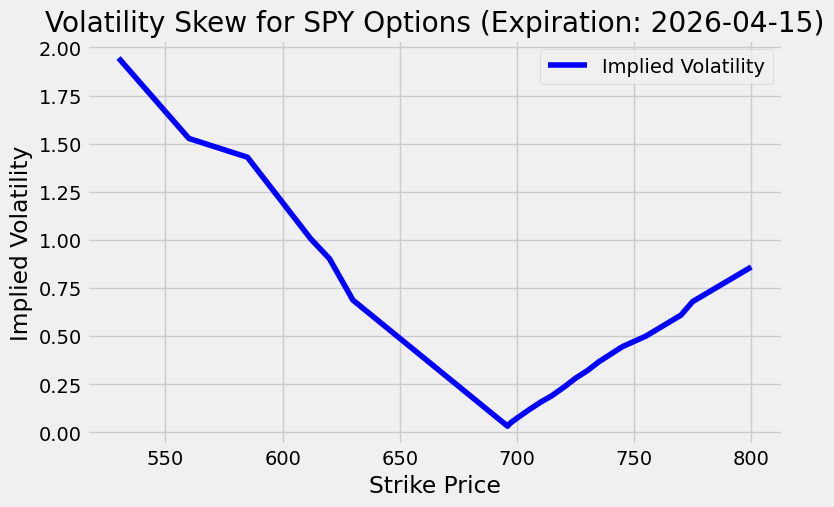

In [4]:
# Fetch option chain data
options = option_chains("SPY")
if options is None:
  raise ValueError("Failed to fetch options data")

# Filter for call options
calls = options[options["optionType"] == "call"]

# Select the nearest expiration with sufficient data
expirations = sorted(set(calls.expiration))
if not expirations:
  raise ValueError("No valid expirations found")
target_expiration = expirations[0]  # Nearest expiration

# Filter for the chosen expiration and remove low volatilities
calls_at_expiry = calls[calls["expiration"] == target_expiration]
filtered_calls_at_expiry = calls_at_expiry[calls_at_expiry.impliedVolatility >= 0.001]

# Plot the volatility skew
plt.figure(figsize=(8, 5))
plt.plot(filtered_calls_at_expiry["strike"], filtered_calls_at_expiry["impliedVolatility"], 'b-', label="Implied Volatility")
plt.title(f"Volatility Skew for SPY Options (Expiration: {target_expiration.date()})")
plt.xlabel("Strike Price")
plt.ylabel("Implied Volatility")
plt.grid(True)
plt.legend()
plt.show()

#### **Analyze Volatility Term Structure**

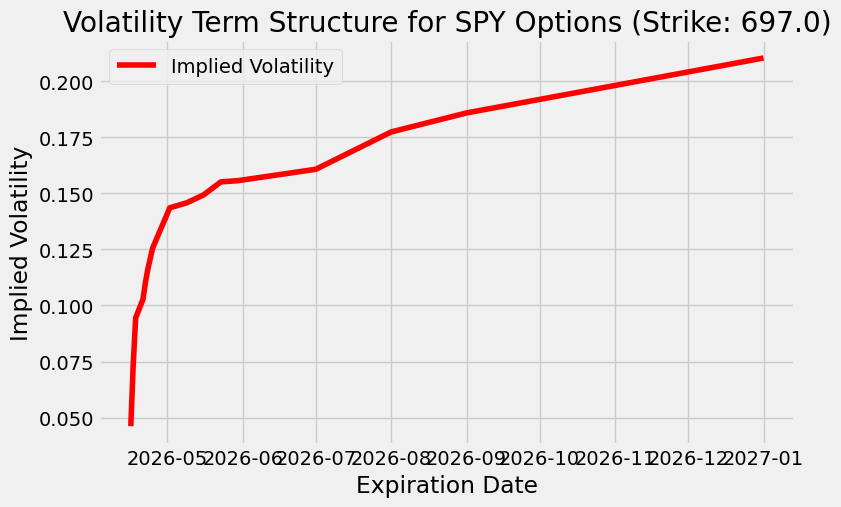

In [5]:
# Select a strike price close to the current stock price
current_price = yf.Ticker("SPY").history(period="1d")["Close"].iloc[-1]
strike = min(calls["strike"], key=lambda x: abs(x - current_price))  # Nearest strike

# Filter for the chosen strike and remove low volatilities
calls_at_strike = calls[calls["strike"] == strike]
filtered_calls_at_strike = calls_at_strike[calls_at_strike.impliedVolatility >= 0.001]

# Plot the volatility term structure
plt.figure(figsize=(8, 5))
plt.plot(filtered_calls_at_strike["expiration"], filtered_calls_at_strike["impliedVolatility"], 'r-', label="Implied Volatility")
plt.title(f"Volatility Term Structure for SPY Options (Strike: {strike})")
plt.xlabel("Expiration Date")
plt.ylabel("Implied Volatility")
plt.grid(True)
plt.legend()
plt.show()

#### **Plot the Volatility Surface**

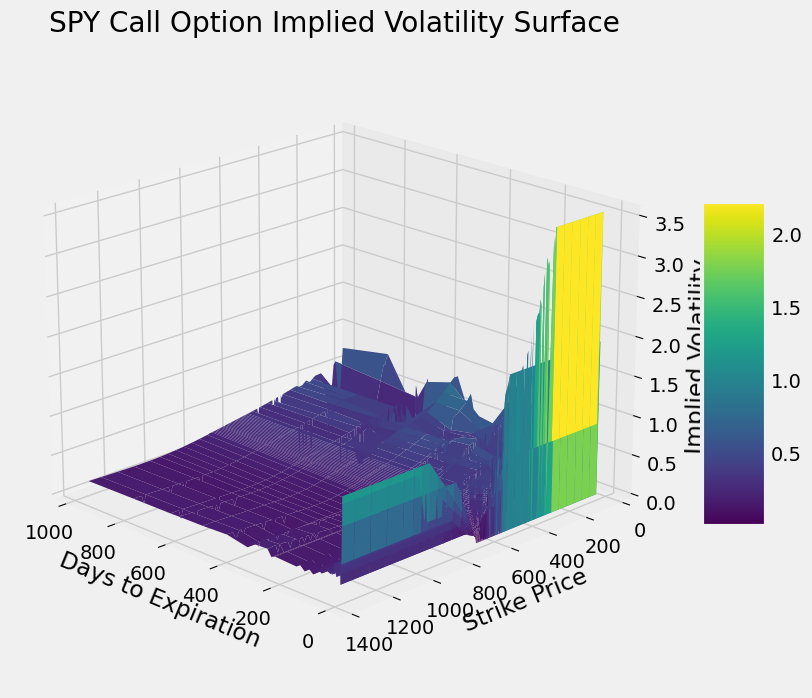

In [6]:
# Create a pivot table for the volatility surface
surface = (
  calls[['daysToExpiration', 'strike', 'impliedVolatility']]
  .pivot_table(values='impliedVolatility', index='strike', columns='daysToExpiration')
)

# Check if the pivot table has sufficient data
if surface.empty or surface.shape[0] < 2 or surface.shape[1] < 2:
  raise ValueError("Insufficient data to plot volatility surface")

# Interpolate missing values for a smoother surface
surface = surface.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')

# Create the 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
x, y, z = surface.columns.values, surface.index.values, surface.values
X, Y = np.meshgrid(x, y)
surf = ax.plot_surface(X, Y, z, cmap='viridis')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
ax.set_xlabel('Days to Expiration')
ax.set_ylabel('Strike Price')
ax.set_zlabel('Implied Volatility')
ax.set_title('SPY Call Option Implied Volatility Surface')
ax.view_init(elev=20, azim=135)
plt.show()